# val_4cases demo

Este notebook replica la idea de `non_iid_wrapper_demo`, pero mostrando el split `val_4cases`:
un subconjunto de validación donde cada muestra puede participar en al menos un patrón composicional de 4 casos.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from omegaconf import OmegaConf

sys.path.append("..")

from visgen.datasets import (
    Cars3D,
    DSprites,
    IRAVEN,
    MPI3D,
    Shapes3D,
    make_validation_subset as split_make_validation_subset,
)
from visgen.datasets.non_iid import NonIIDWrapper, subset_with_four_case_support
from visgen.utils.general import register_resolvers

register_resolvers()


In [2]:
DATASET_CONFIG_DIR = Path("../configs/datasets")
# Ajusta esta ruta para apuntar a la carpeta base donde están tus datasets.
# Si los paths en los YAML son absolutos, se respetan tal cual.
DATASETS_BASE_PATH = Path("/home/araymond/investigacion/scalable-compositional-generalization/data")

DATASET_CLASSES = {
    "dsprites": DSprites,
    "mpi3d": MPI3D,
    "shapes3d": Shapes3D,
    "cars3d": Cars3D,
    "iraven": IRAVEN,
}


def load_training_cfg(name, datasets_base_path=DATASETS_BASE_PATH):
    cfg = OmegaConf.load(DATASET_CONFIG_DIR / f"{name}.yml").data.training
    raw_path = Path(cfg.path)

    if not raw_path.is_absolute():
        try:
            relative_to_data = raw_path.relative_to("data")
        except ValueError:
            relative_to_data = raw_path
        cfg.path = str(Path(datasets_base_path) / relative_to_data)

    return cfg


def make_validation_subset(name, seed=0, datasets_base_path=DATASETS_BASE_PATH):
    cfg = load_training_cfg(name, datasets_base_path=datasets_base_path)
    dataset = DATASET_CLASSES[name](**cfg)
    _, val_data = split_make_validation_subset(
        dataset,
        val_fraction=cfg.val_fraction,
        seed=seed,
        num_ood_val=cfg.num_ood_val if "num_ood_val" in cfg else 1,
    )
    return cfg, val_data


In [3]:
def plot_quad(images, targets, title):
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    fig.suptitle(title)
    for idx, ax in enumerate(axes):
        img = images[idx]
        if torch.is_tensor(img):
            img = img.detach().cpu().numpy()
        if img.ndim == 3 and img.shape[0] in (1, 3):
            img = np.moveaxis(img, 0, -1)
        ax.imshow(img.squeeze(), cmap="gray")
        ax.axis("off")
        ax.set_title(str(np.asarray(targets[idx]).tolist()))
    plt.tight_layout()



Dataset: dsprites
validation size: 73728
val_4cases size: 68036

Dataset: mpi3d
validation size: 103680
val_4cases size: 87651

Dataset: shapes3d
validation size: 48000
val_4cases size: 26187

Dataset: cars3d
validation size: 1756
val_4cases size: 1573

Dataset: iraven
validation size: 16000
val_4cases size: 16000


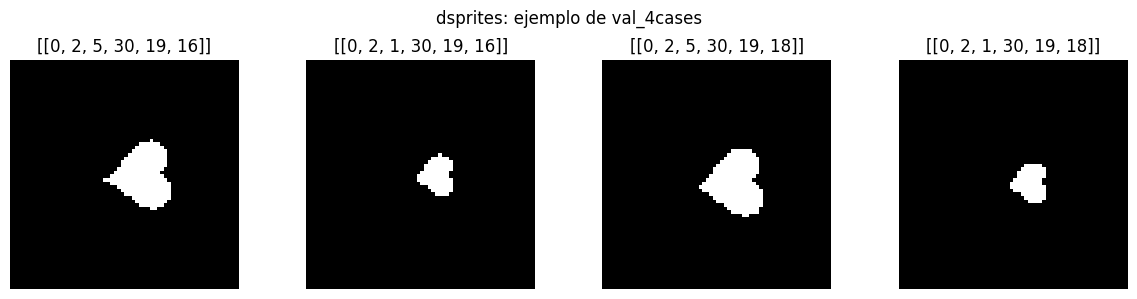

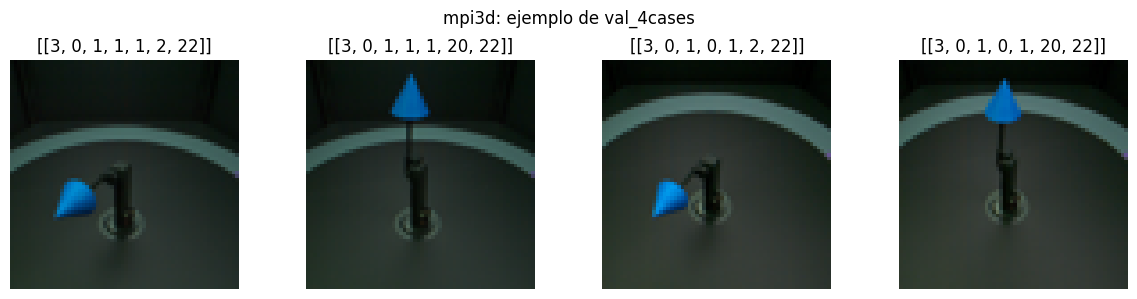

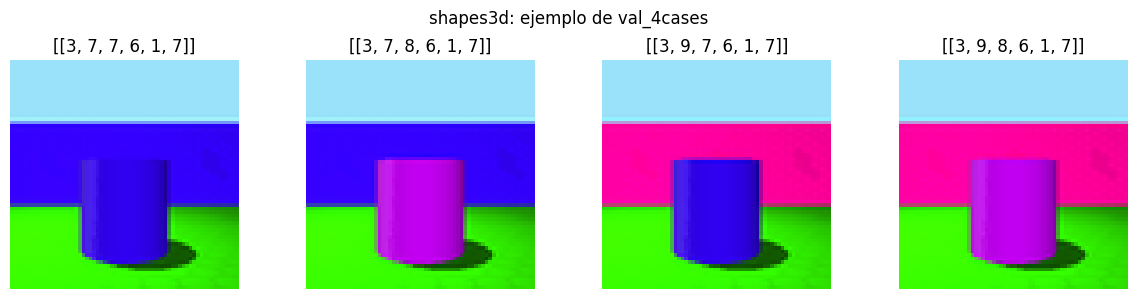

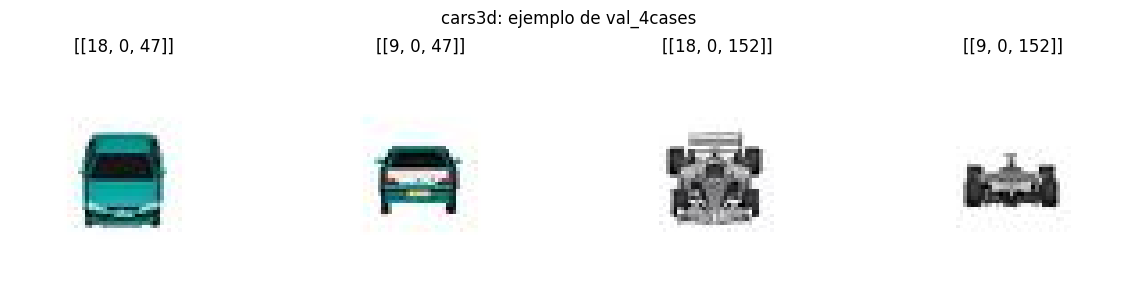

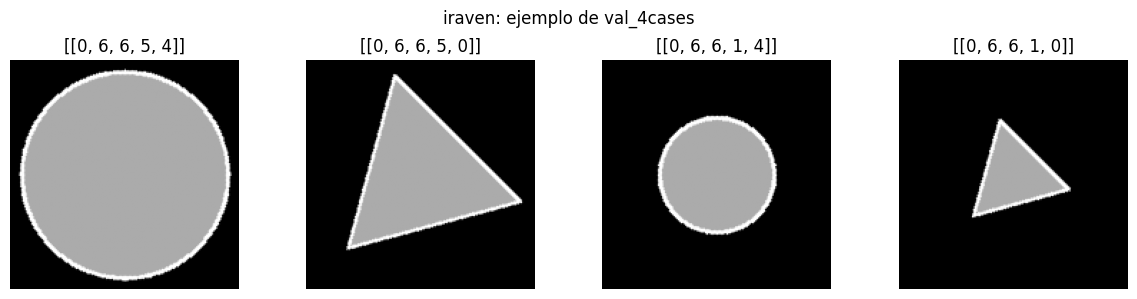

In [4]:
SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

for name in DATASET_CLASSES:
    print(f"\nDataset: {name}")
    cfg, val_data = make_validation_subset(name, seed=SEED)
    allowed_attributes = list(cfg.targets) if cfg.targets else [attr.name for attr in cfg.attributes]
    shared_other_attributes = True
    if "non_iid" in cfg and cfg.non_iid is not None and not isinstance(cfg.non_iid, str):
        shared_other_attributes = cfg.non_iid.get("shared_other_attributes", True)

    val_4cases = subset_with_four_case_support(
        val_data,
        allowed_attributes=allowed_attributes,
        shared_other_attributes=shared_other_attributes,
    )
    print(f"validation size: {len(val_data)}")
    print(f"val_4cases size: {len(val_4cases)}")

    wrapper = NonIIDWrapper(
        val_4cases,
        shared_other_attributes=shared_other_attributes,
        seed=SEED,
        allowed_attributes=allowed_attributes,
    )
    images, targets = wrapper[0]
    plot_quad(images, targets, f"{name}: ejemplo de val_4cases")


## Validaciones de sampling adversarial y `unpredictable_target`

Las siguientes celdas validan, sin depender de imágenes reales, las invariantes que deben cumplir los modos de sampling:

- `non_iid`: los primeros tres ejemplos y el target forman el cuadrilátero composicional esperado.
- `unpredictable_target` con `num_unpredictable_attributes=1`: se mantiene el atributo inferido por el primer eje del cuadrilátero y se rompe el atributo que normalmente se inferiría desde el segundo ejemplo del contexto.
- `unpredictable_target` con `num_unpredictable_attributes=2`: se rompen ambos atributos del cuadrilátero.
- `adversarial`: el target no comparte valores de atributo con los primeros tres ejemplos.
    


In [5]:
import itertools
from collections import Counter


class ToyQuadrilateralDataset(torch.utils.data.Dataset):
    """Dataset cartesiano pequeño para validar targets sin depender de imágenes."""

    def __init__(self, attribute_cardinalities=(5, 5, 5)):
        targets = list(itertools.product(*[range(n) for n in attribute_cardinalities]))
        self._dataset_targets = np.asarray(targets)
        self._attribute_values = [list(range(n)) for n in attribute_cardinalities]

    def __len__(self):
        return len(self._dataset_targets)

    def __getitem__(self, index):
        image = torch.tensor([float(index)])
        return image, self._dataset_targets[index]


def as_rows(targets):
    rows = targets.detach().cpu().numpy() if torch.is_tensor(targets) else np.asarray(targets)
    return rows.reshape(4, -1)


def prefix_signature(rows):
    """Identifica los dos atributos del cuadrilátero usando el orden del wrapper.

    Para un prefijo `(a,c), (a,d), (b,c)`, el atributo que cambia entre las
    filas 0 y 1 es `attr_b`, y el que cambia entre 0 y 2 es `attr_a`.
    """
    first_three = rows[:3]
    attr_b = [idx for idx in range(rows.shape[1]) if first_three[0, idx] != first_three[1, idx]]
    attr_a = [idx for idx in range(rows.shape[1]) if first_three[0, idx] != first_three[2, idx]]
    shared = [idx for idx in range(rows.shape[1]) if len(set(first_three[:, idx])) == 1]
    assert len(attr_a) == 1, f"expected one attr_a, got {attr_a} for rows={rows}"
    assert len(attr_b) == 1, f"expected one attr_b, got {attr_b} for rows={rows}"
    assert attr_a[0] != attr_b[0], f"attr_a and attr_b should differ: {rows}"
    return attr_a[0], attr_b[0], shared


def assert_non_iid_quadrilateral(rows):
    attr_a, attr_b, shared = prefix_signature(rows)
    target = rows[3]
    first_three = rows[:3]
    assert target[attr_a] == first_three[2, attr_a]
    assert target[attr_b] == first_three[1, attr_b]
    for attr_idx in shared:
        assert target[attr_idx] == first_three[0, attr_idx]


def assert_unpredictable_target(rows, num_unpredictable_attributes):
    attr_a, attr_b, shared = prefix_signature(rows)
    target = rows[3]
    first_three = rows[:3]

    if num_unpredictable_attributes == 1:
        assert target[attr_a] == first_three[2, attr_a]
        assert target[attr_b] not in set(first_three[:, attr_b])
    elif num_unpredictable_attributes == 2:
        assert target[attr_a] not in set(first_three[:, attr_a])
        assert target[attr_b] not in set(first_three[:, attr_b])
    else:
        raise ValueError("num_unpredictable_attributes must be 1 or 2")

    for attr_idx in shared:
        assert target[attr_idx] == first_three[0, attr_idx]


def assert_adversarial_target(rows):
    target = rows[3]
    first_three = rows[:3]
    for attr_idx in range(rows.shape[1]):
        assert target[attr_idx] not in set(first_three[:, attr_idx])


def split_diversity_summary(wrapper, max_items=None):
    n = len(wrapper) if max_items is None else min(len(wrapper), max_items)
    base_targets = set()
    attr_pairs = []

    for idx in range(n):
        _, targets = wrapper[idx]
        rows = as_rows(targets)
        attr_a, attr_b, _ = prefix_signature(rows)
        base_targets.add(tuple(rows[0].tolist()))
        attr_pairs.append((attr_a, attr_b))

    return {
        "n": n,
        "unique_base_targets": len(base_targets),
        "unique_attr_pairs": len(set(attr_pairs)),
        "attr_pairs": Counter(attr_pairs),
    }


def print_split_diversity_summary(summary, prefix="  "):
    print(f"{prefix}n: {summary['n']}")
    print(f"{prefix}unique base targets: {summary['unique_base_targets']}")
    print(f"{prefix}unique attr pairs: {summary['unique_attr_pairs']}")
    print(f"{prefix}top attr pairs: {summary['attr_pairs'].most_common(5)}")


def assert_sampling_mode(wrapper, expected_mode, *, num_unpredictable_attributes=None, index=0):
    _, targets = wrapper[index]
    rows = as_rows(targets)
    if expected_mode == "non_iid":
        assert_non_iid_quadrilateral(rows)
    elif expected_mode == "unpredictable_target":
        assert_unpredictable_target(rows, num_unpredictable_attributes)
    elif expected_mode == "adversarial":
        assert_adversarial_target(rows)
    else:
        raise ValueError(f"Unknown expected mode: {expected_mode}")
    return rows
    


In [6]:
toy_dataset = ToyQuadrilateralDataset(attribute_cardinalities=(5, 5, 5))

sampling_checks = [
    (
        "non_iid",
        NonIIDWrapper(toy_dataset, sampling_mode="non_iid", seed=SEED),
        {},
    ),
    (
        "unpredictable_target_1",
        NonIIDWrapper(
            toy_dataset,
            sampling_mode="unpredictable_target",
            num_unpredictable_attributes=1,
            seed=SEED,
        ),
        {"num_unpredictable_attributes": 1},
    ),
    (
        "unpredictable_target_2",
        NonIIDWrapper(
            toy_dataset,
            sampling_mode="unpredictable_target",
            num_unpredictable_attributes=2,
            seed=SEED,
        ),
        {"num_unpredictable_attributes": 2},
    ),
    (
        "adversarial",
        NonIIDWrapper(toy_dataset, sampling_mode="adversarial", seed=SEED),
        {},
    ),
]

for label, wrapper, kwargs in sampling_checks:
    expected_mode = "unpredictable_target" if label.startswith("unpredictable") else label
    rows = assert_sampling_mode(wrapper, expected_mode, **kwargs)
    print(f"{label}: OK")
    print(rows)

# Chequeo adicional: los candidatos determinísticos deben ser reproducibles.
deterministic_ut2 = NonIIDWrapper(
    toy_dataset,
    sampling_mode="unpredictable_target",
    num_unpredictable_attributes=2,
    deterministic=True,
    precompute_deterministic=True,
    max_deterministic_candidates=8,
)
assert len(deterministic_ut2) <= 8
_, first_targets = deterministic_ut2[0]
_, second_targets = deterministic_ut2[0]
assert torch.equal(first_targets, second_targets)
assert_unpredictable_target(as_rows(first_targets), num_unpredictable_attributes=2)
print("deterministic unpredictable_target_2: OK")
    


non_iid: OK
[[4 4 4]
 [4 4 0]
 [4 1 4]
 [4 1 0]]
unpredictable_target_1: OK
[[4 4 4]
 [4 4 0]
 [4 1 4]
 [4 1 2]]
unpredictable_target_2: OK
[[4 4 4]
 [4 4 0]
 [4 1 4]
 [4 2 3]]
adversarial: OK
[[4 4 4]
 [4 4 0]
 [4 1 4]
 [2 2 3]]
deterministic unpredictable_target_2: OK


## Validación de los configs nuevos de evaluación

Esta celda revisa que cada config `*_unpredictable_target_1.yml` y `*_unpredictable_target_2.yml` declare los splits compactos de evaluación:

- Train: `ut1_train`, `ut2_train`, `adv_train`.
- Test: `ut1_test`, `ut2_test`, `adv_test`.

También valida que cada split sea determinístico, precomputado, y use `num_quadrilaterals: 512` como límite máximo configurable.
    


In [10]:
UNPREDICTABLE_DATASETS = ["cars3d", "clevr", "dsprites", "iraven", "mpi3d", "shapes3d"]
TRAIN_EVAL_SPLITS = ("ut1_train", "ut2_train", "adv_train")
TEST_EVAL_SPLITS = ("ut1_test", "ut2_test", "adv_test")
EXPECTED_NUM_QUADRILATERALS = 512
EXPECTED_MAX_DETERMINISTIC_RESAMPLE_ATTEMPTS = 50000

BASE_CFG_PATH = Path("../configs/base.yml")


def load_unpredictable_cfg(dataset_name, level):
    path = DATASET_CONFIG_DIR / f"{dataset_name}_unpredictable_target_{level}.yml"
    base_cfg = OmegaConf.load(BASE_CFG_PATH)
    data_cfg = OmegaConf.load(path)
    cfg = OmegaConf.merge(base_cfg, data_cfg)
    return path, cfg


def assert_eval_split_overrides(section_cfg, expected_splits):
    for split_name in expected_splits:
        assert split_name in section_cfg.eval_splits, f"missing eval_splits.{split_name}"
        assert split_name in section_cfg.non_iid.apply_to, f"{split_name} is not in apply_to"
        override = section_cfg.non_iid.split_overrides[split_name]
        assert override.deterministic is True, f"{split_name} must be deterministic"
        assert override.precompute_deterministic is True, f"{split_name} must precompute candidates"
        assert override.deterministic_sampling_strategy == "random"
        assert override.num_quadrilaterals == EXPECTED_NUM_QUADRILATERALS
        assert (
            override.max_deterministic_resample_attempts
            == EXPECTED_MAX_DETERMINISTIC_RESAMPLE_ATTEMPTS
        )

        if split_name.startswith("ut1"):
            assert override.sampling_mode == "unpredictable_target"
            assert override.num_unpredictable_attributes == 1
        elif split_name.startswith("ut2"):
            assert override.sampling_mode == "unpredictable_target"
            assert override.num_unpredictable_attributes == 2
        elif split_name.startswith("adv"):
            assert override.sampling_mode == "adversarial"
        else:
            raise AssertionError(f"Unexpected split name: {split_name}")


for dataset_name in UNPREDICTABLE_DATASETS:
    for level in (1, 2):
        path, cfg = load_unpredictable_cfg(dataset_name, level)
        assert cfg.data.training.non_iid.sampling_mode == "unpredictable_target"
        assert cfg.data.training.non_iid.num_unpredictable_attributes == level
        assert_eval_split_overrides(cfg.data.training, TRAIN_EVAL_SPLITS)
        assert_eval_split_overrides(cfg.data.testing, TEST_EVAL_SPLITS)
        print(f"{path.name}: OK")
    


cars3d_unpredictable_target_1.yml: OK
cars3d_unpredictable_target_2.yml: OK
clevr_unpredictable_target_1.yml: OK
clevr_unpredictable_target_2.yml: OK
dsprites_unpredictable_target_1.yml: OK
dsprites_unpredictable_target_2.yml: OK
iraven_unpredictable_target_1.yml: OK
iraven_unpredictable_target_2.yml: OK
mpi3d_unpredictable_target_1.yml: OK
mpi3d_unpredictable_target_2.yml: OK
shapes3d_unpredictable_target_1.yml: OK
shapes3d_unpredictable_target_2.yml: OK


## Validación opcional sobre datasets reales

La siguiente celda intenta construir los splits reales de train/test y aplicar los wrappers determinísticos de los configs. Si los archivos de datos no están disponibles localmente, el dataset se marca como `SKIP`. Cuando los datos sí existen, se valida una muestra de cada split (`ut1`, `ut2`, `adv`) con las mismas invariantes semánticas de arriba.
    


In [8]:
def patch_dataset_path(cfg, datasets_base_path=DATASETS_BASE_PATH):
    cfg = OmegaConf.create(OmegaConf.to_container(cfg, resolve=True))
    raw_path = Path(cfg.path)
    if not raw_path.is_absolute():
        try:
            relative_to_data = raw_path.relative_to("data")
        except ValueError:
            relative_to_data = raw_path
        cfg.path = str(Path(datasets_base_path) / relative_to_data)
    return cfg


def make_train_and_test_datasets(dataset_name, level=1, seed=SEED):
    _, full_cfg = load_unpredictable_cfg(dataset_name, level)
    train_cfg = patch_dataset_path(full_cfg.data.training)
    test_cfg = patch_dataset_path(full_cfg.data.testing)

    train_full = DATASET_CLASSES[dataset_name](**train_cfg)
    train_base, _ = split_make_validation_subset(
        train_full,
        val_fraction=train_cfg.val_fraction,
        seed=seed,
        num_ood_val=train_cfg.num_ood_val if "num_ood_val" in train_cfg else 1,
    )
    test_base = DATASET_CLASSES[dataset_name](**test_cfg)
    return full_cfg, train_base, test_base


def make_wrapper_for_config_split(base_dataset, section_cfg, split_name):
    override = section_cfg.non_iid.split_overrides[split_name]
    allowed_attributes = list(section_cfg.targets) if section_cfg.targets else [attr.name for attr in section_cfg.attributes]
    return NonIIDWrapper(
        base_dataset,
        seed=override.seed,
        allowed_attributes=allowed_attributes,
        shared_other_attributes=section_cfg.non_iid.get("shared_other_attributes", True),
        sampling_mode=override.sampling_mode,
        deterministic=override.deterministic,
        precompute_deterministic=override.precompute_deterministic,
        max_deterministic_candidates=override.num_quadrilaterals,
        num_unpredictable_attributes=override.get("num_unpredictable_attributes", 1),
        deterministic_sampling_strategy=override.get("deterministic_sampling_strategy", "random"),
        max_deterministic_resample_attempts=override.get(
            "max_deterministic_resample_attempts",
            None,
        ),
    )


def validate_configured_split(base_dataset, section_cfg, split_name):
    wrapper = make_wrapper_for_config_split(base_dataset, section_cfg, split_name)
    assert len(wrapper) <= EXPECTED_NUM_QUADRILATERALS
    if len(wrapper) == 0:
        print(f"  {split_name}: SKIP no deterministic candidates found")
        return

    _, targets = wrapper[0]
    rows = as_rows(targets)
    if split_name.startswith("ut1"):
        assert_unpredictable_target(rows, num_unpredictable_attributes=1)
    elif split_name.startswith("ut2"):
        assert_unpredictable_target(rows, num_unpredictable_attributes=2)
    elif split_name.startswith("adv"):
        assert_adversarial_target(rows)
    else:
        raise AssertionError(f"Unexpected split name: {split_name}")
    print(f"  {split_name}: OK ({len(wrapper)} quadrilaterals)")
    print_split_diversity_summary(split_diversity_summary(wrapper))





In [ ]:
for dataset_name in [name for name in UNPREDICTABLE_DATASETS if name in DATASET_CLASSES]:
    print(f"\nDataset: {dataset_name}")
    try:
        full_cfg, train_base, test_base = make_train_and_test_datasets(dataset_name, level=1)
    except Exception as exc:
        print(f"  SKIP: could not load local data ({type(exc).__name__}: {exc})")
        continue

    for split_name in TRAIN_EVAL_SPLITS:
        validate_configured_split(train_base, full_cfg.data.training, split_name)
    for split_name in TEST_EVAL_SPLITS:
        validate_configured_split(test_base, full_cfg.data.testing, split_name)
    


Dataset: cars3d
  ut1_train: showing 3/512 deterministic examples
  ut1_train example 0
    attr_a (changes rows 0 -> 2): 2
    attr_b (changes rows 0 -> 1): 1
    shared attrs: [0]
    targets:
    sample 0: [13, 1, 154]
    sample 1: [13, 0, 154]
    sample 2: [13, 1, 166]
    sample 3: [13, 2, 166]
    expected: attr_a compositional, attr_b unseen in prefix
    attr_a target == row2? 166 == 166
    attr_b target unseen? 2 not in [np.int64(0), np.int64(1)]
  ut1_train example 1
    attr_a (changes rows 0 -> 2): 0
    attr_b (changes rows 0 -> 1): 2
    shared attrs: [1]
    targets:
    sample 0: [18, 2, 33]
    sample 1: [18, 2, 162]
    sample 2: [20, 2, 33]
    sample 3: [20, 2, 3]
    expected: attr_a compositional, attr_b unseen in prefix
    attr_a target == row2? 20 == 20
    attr_b target unseen? 3 not in [np.int64(33), np.int64(162)]
  ut1_train example 2
    attr_a (changes rows 0 -> 2): 2
    attr_b (changes rows 0 -> 1): 0
    shared attrs: [1]
    targets:
    sample 0:

/tmp/ipykernel_4175559/681986659.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 4, figsize=(12, 3))


  ut2_test: showing 3/512 deterministic examples
  ut2_test example 0
    attr_a (changes rows 0 -> 2): 5
    attr_b (changes rows 0 -> 1): 3
    shared attrs: [0, 1, 2, 4]
    targets:
    sample 0: [0, 2, 2, 35, 27, 28]
    sample 1: [0, 2, 2, 23, 27, 28]
    sample 2: [0, 2, 2, 35, 27, 12]
    sample 3: [0, 2, 2, 3, 27, 8]
    expected: attr_a and attr_b unseen in prefix
    attr_a target unseen? 8 not in [np.int64(12), np.int64(28)]
    attr_b target unseen? 3 not in [np.int64(23), np.int64(35)]
  ut2_test example 1
    attr_a (changes rows 0 -> 2): 4
    attr_b (changes rows 0 -> 1): 2
    shared attrs: [0, 1, 3, 5]
    targets:
    sample 0: [0, 0, 1, 38, 27, 4]
    sample 1: [0, 0, 4, 38, 27, 4]
    sample 2: [0, 0, 1, 38, 19, 4]
    sample 3: [0, 0, 2, 38, 0, 4]
    expected: attr_a and attr_b unseen in prefix
    attr_a target unseen? 0 not in [np.int64(19), np.int64(27)]
    attr_b target unseen? 2 not in [np.int64(1), np.int64(4)]
  ut2_test example 2
    attr_a (changes row

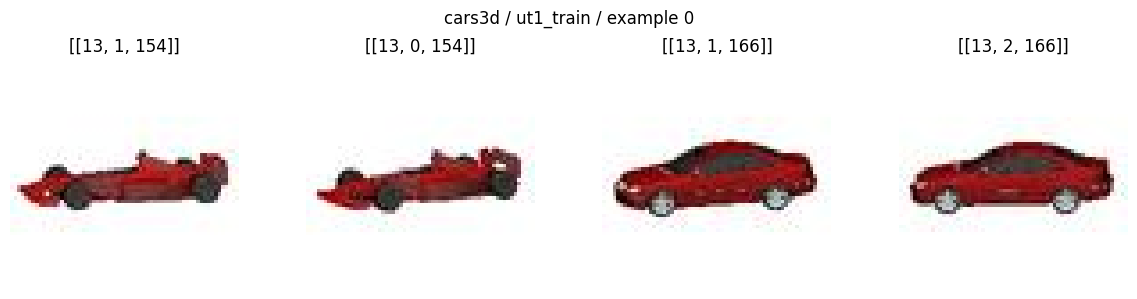

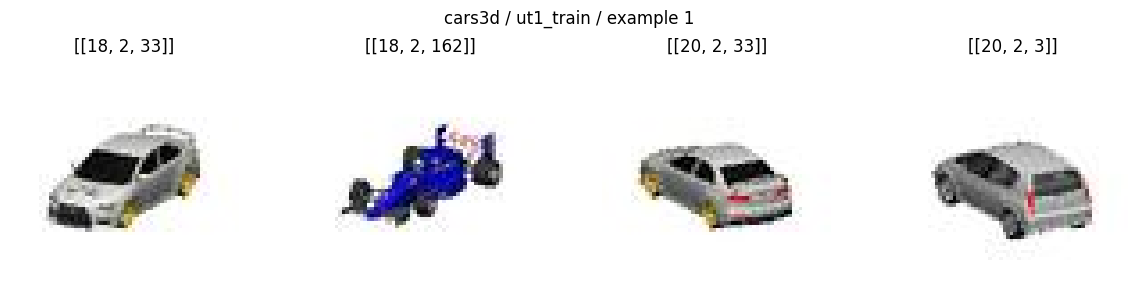

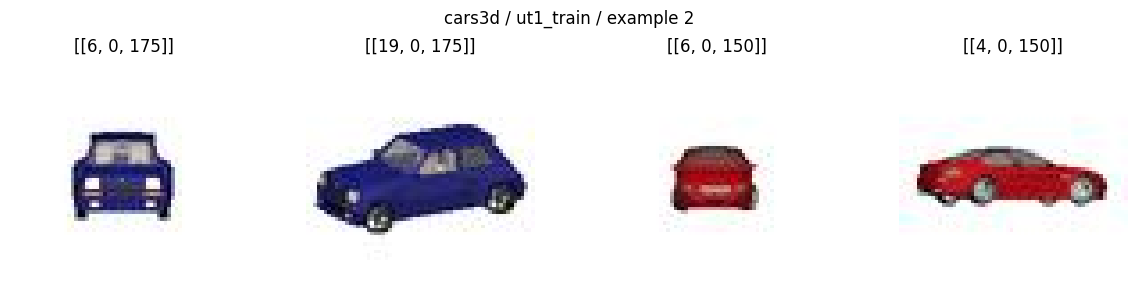

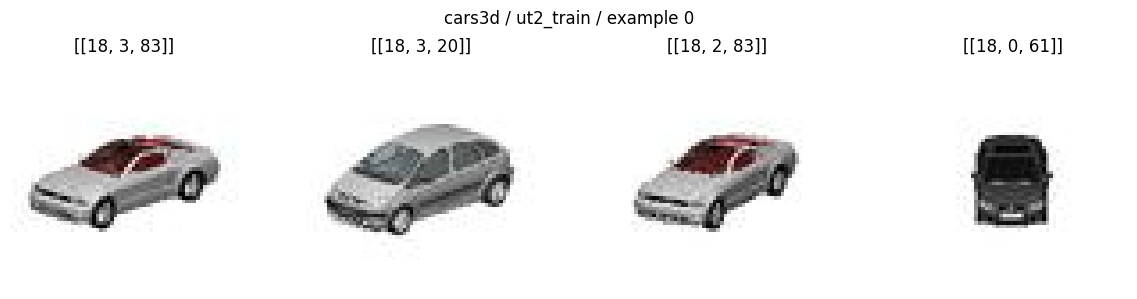

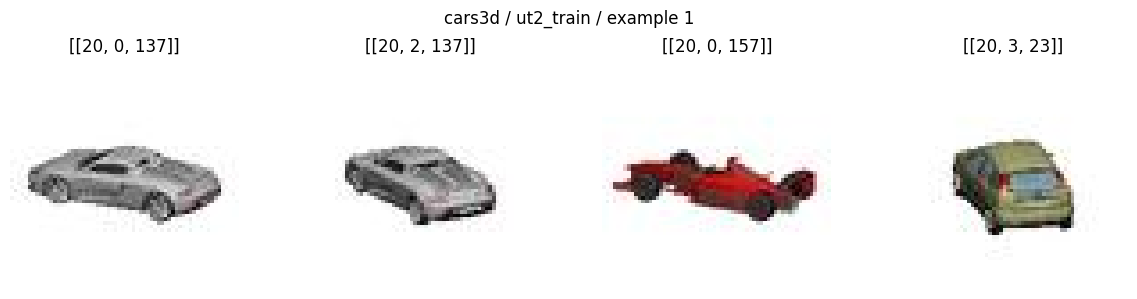

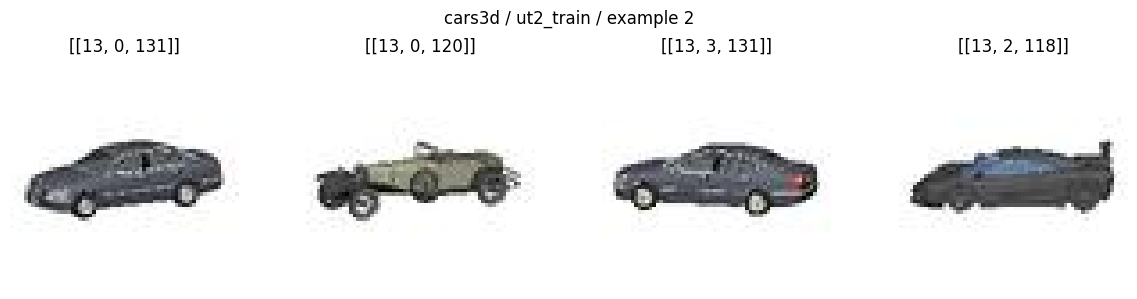

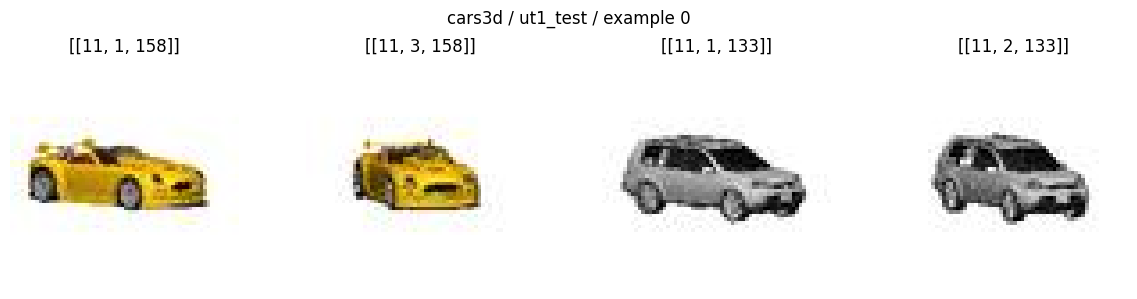

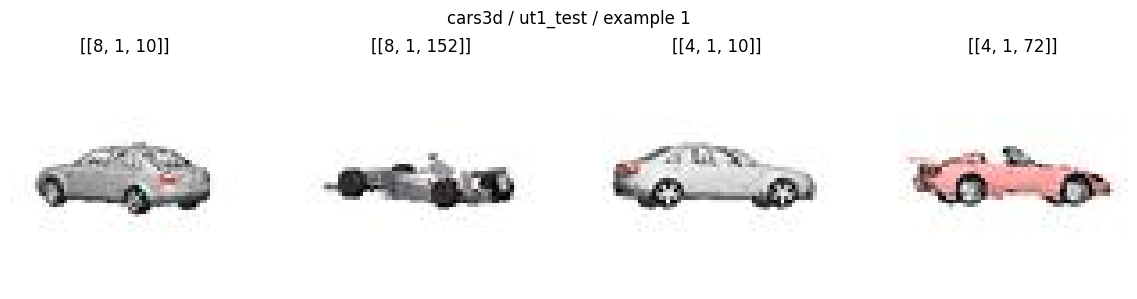

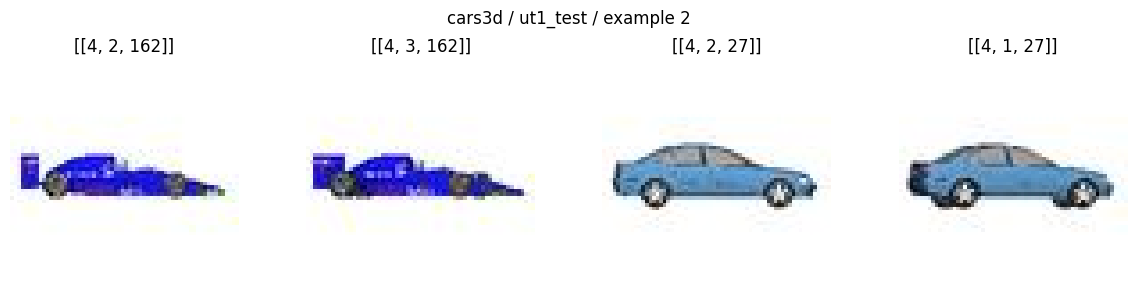

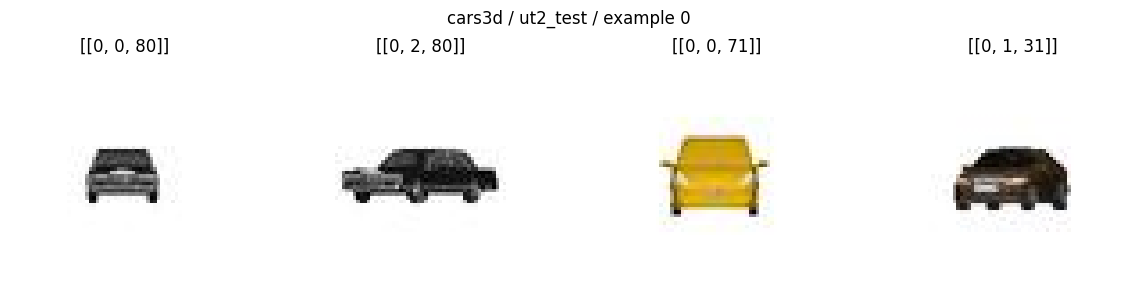

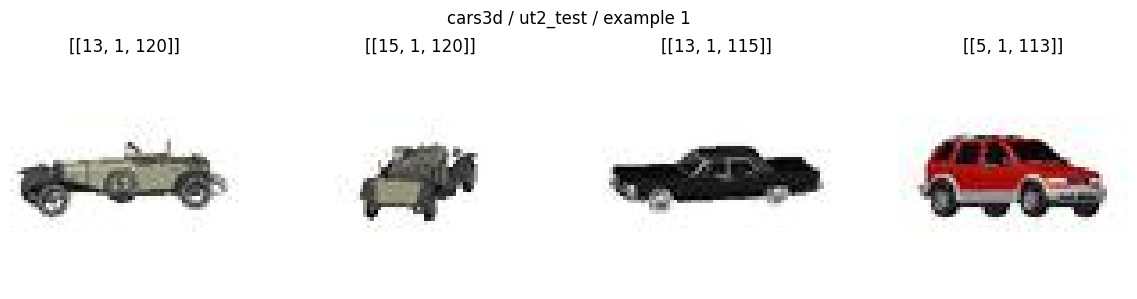

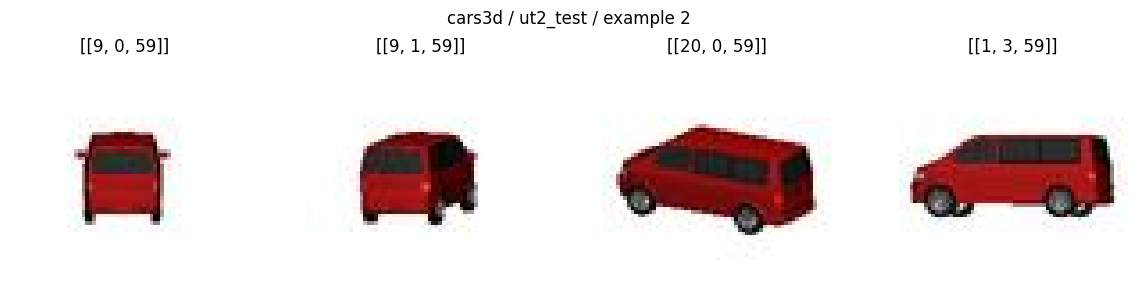

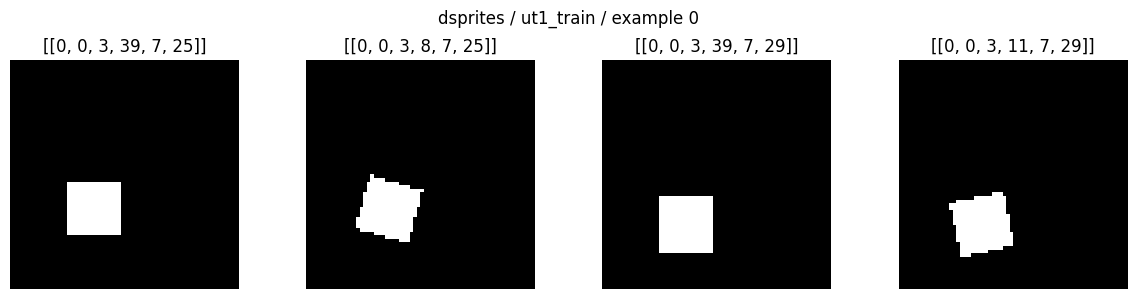

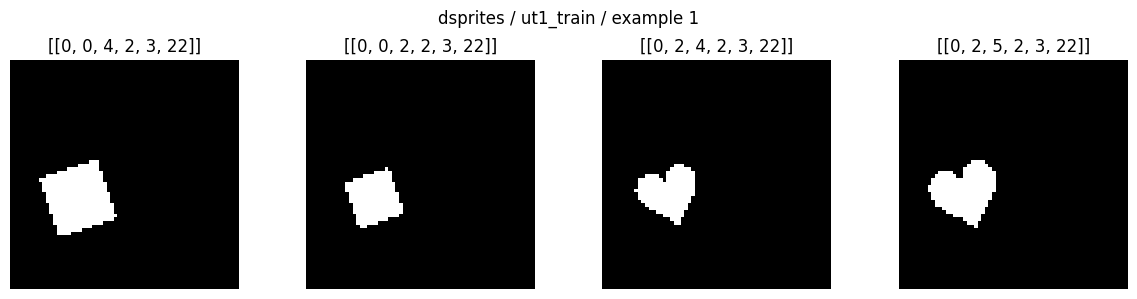

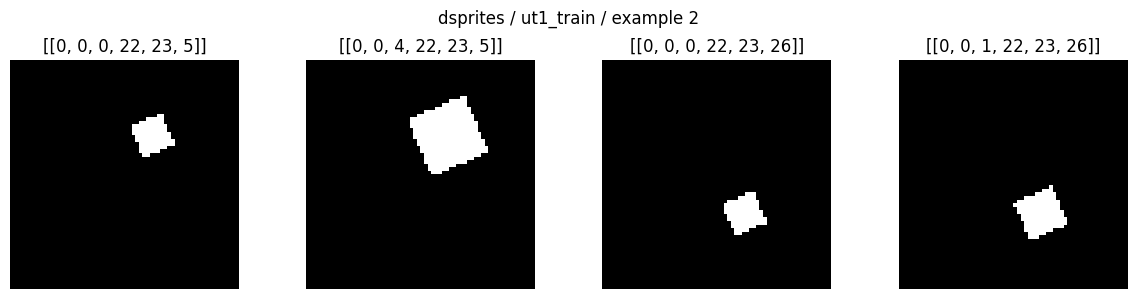

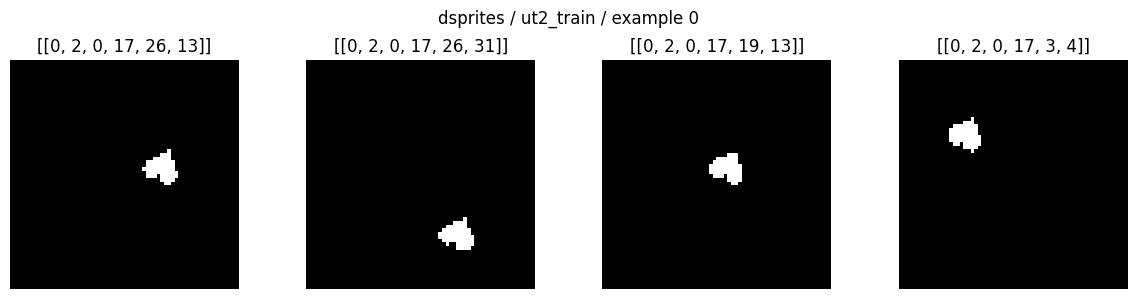

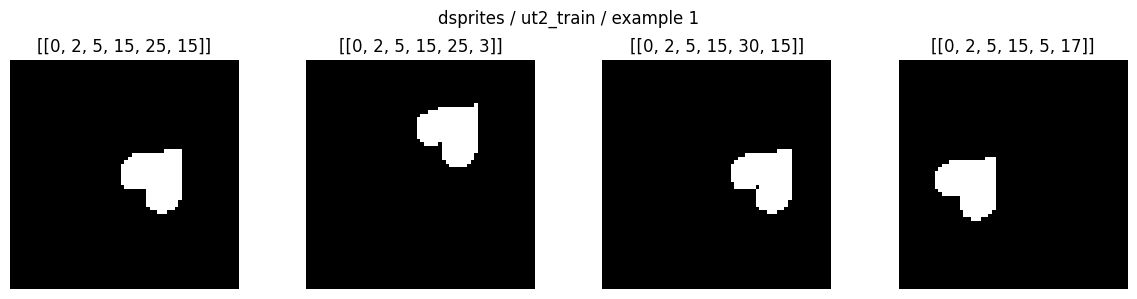

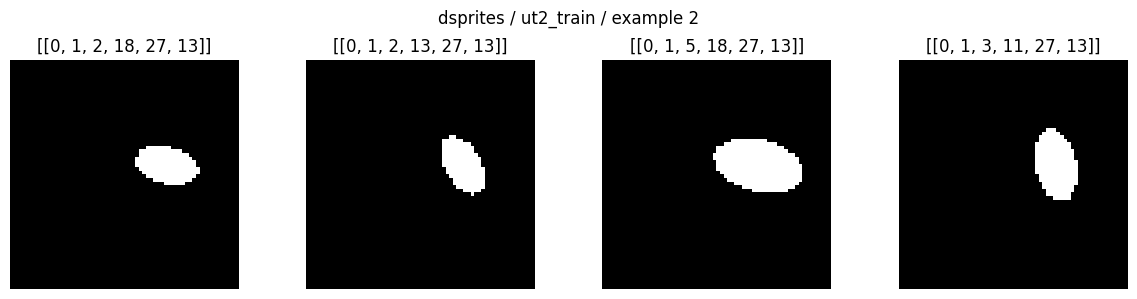

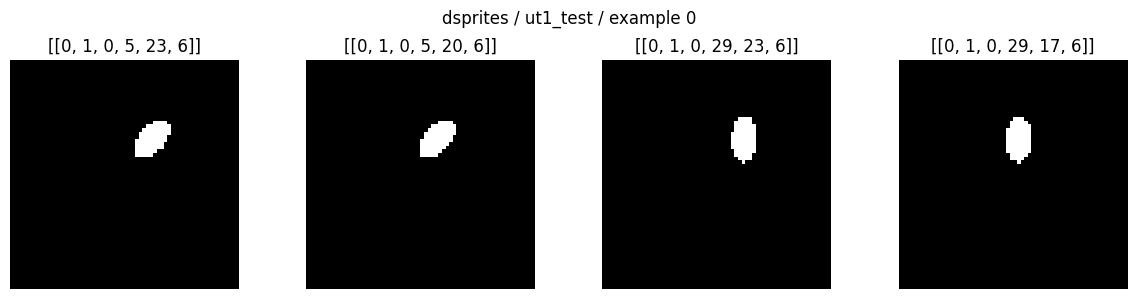

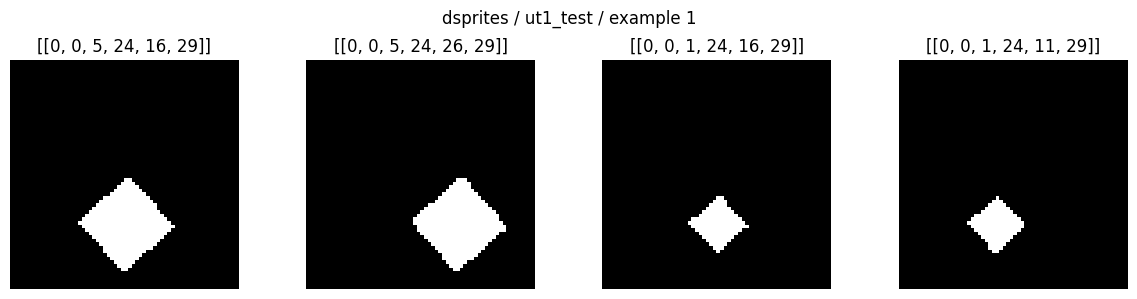

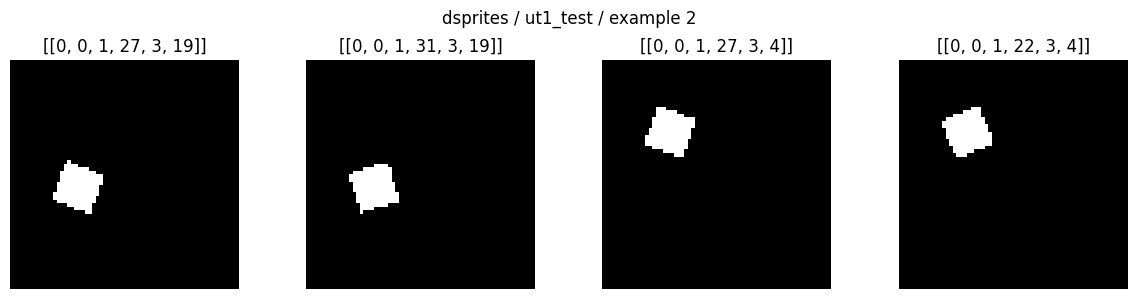

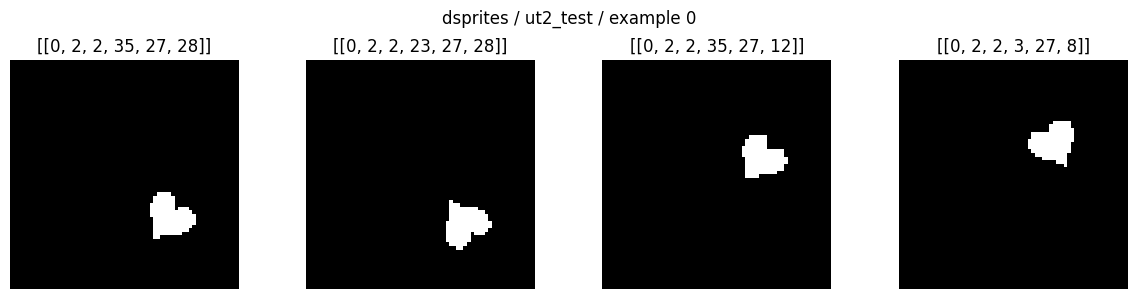

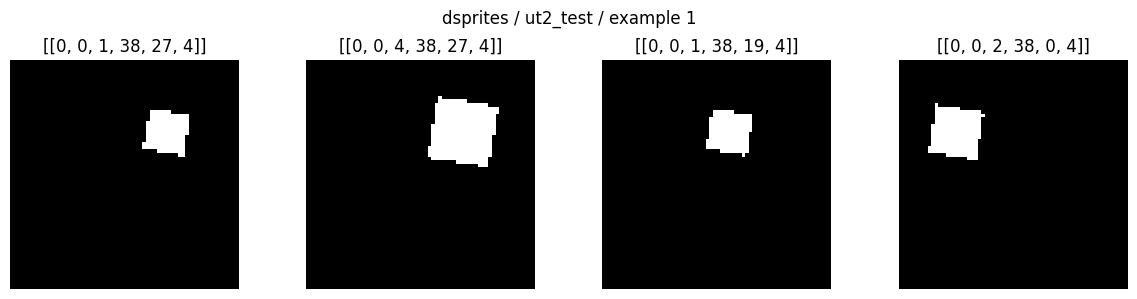

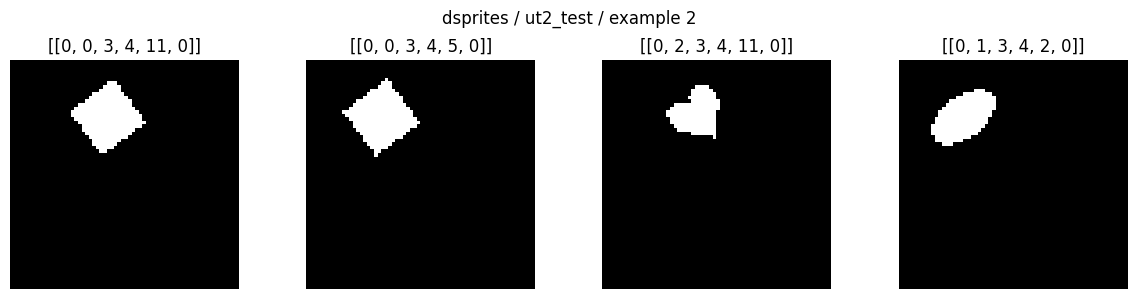

In [11]:
# Visual inspection of deterministic ut1 / ut2 / adversarial splits.
# Run this after the final validation cell.

VISUAL_DATASETS = ["cars3d", "dsprites"]#, "iraven", "mpi3d", "shapes3d"]
VISUAL_SPLITS = [
    ("ut1_train", "train"),
    ("ut2_train", "train"),
    #("adv_train", "train"),
    ("ut1_test", "test"),
    ("ut2_test", "test"),
    #("adv_test", "test"),
]
N_VISUAL_EXAMPLES_PER_SPLIT = 3


def target_rows_to_table(targets):
    rows = as_rows(targets)
    return "\n".join(
        f"    sample {idx}: {row.tolist()}" for idx, row in enumerate(rows)
    )


def print_split_semantics(split_name, targets):
    rows = as_rows(targets)
    first_three = rows[:3]
    target = rows[3]
    attr_a, attr_b, shared = prefix_signature(rows)

    print(f"    attr_a (changes rows 0 -> 2): {attr_a}")
    print(f"    attr_b (changes rows 0 -> 1): {attr_b}")
    print(f"    shared attrs: {shared}")
    print("    targets:")
    print(target_rows_to_table(targets))

    if split_name.startswith("ut1"):
        print("    expected: attr_a compositional, attr_b unseen in prefix")
        print(f"    attr_a target == row2? {target[attr_a]} == {first_three[2, attr_a]}")
        print(
            "    attr_b target unseen? "
            f"{target[attr_b]} not in {sorted(set(first_three[:, attr_b]))}"
        )
    elif split_name.startswith("ut2"):
        print("    expected: attr_a and attr_b unseen in prefix")
        print(
            "    attr_a target unseen? "
            f"{target[attr_a]} not in {sorted(set(first_three[:, attr_a]))}"
        )
        print(
            "    attr_b target unseen? "
            f"{target[attr_b]} not in {sorted(set(first_three[:, attr_b]))}"
        )
    elif split_name.startswith("adv"):
        print("    expected: every target attribute unseen in prefix")
        for attr_idx in range(rows.shape[1]):
            print(
                f"    attr {attr_idx}: "
                f"{target[attr_idx]} not in {sorted(set(first_three[:, attr_idx]))}"
            )


def plot_configured_split_examples(
    dataset_name,
    split_name,
    base_dataset,
    section_cfg,
    max_examples=N_VISUAL_EXAMPLES_PER_SPLIT,
):
    wrapper = make_wrapper_for_config_split(base_dataset, section_cfg, split_name)

    if len(wrapper) == 0:
        print(f"  {split_name}: SKIP no deterministic candidates found")
        return

    n_examples = min(max_examples, len(wrapper))
    print(f"  {split_name}: showing {n_examples}/{len(wrapper)} deterministic examples")

    for example_idx in range(n_examples):
        images, targets = wrapper[example_idx]

        # Keep the assert-based validation too, so visual examples fail loudly
        # if something is semantically wrong.
        if split_name.startswith("ut1"):
            assert_unpredictable_target(as_rows(targets), num_unpredictable_attributes=1)
        elif split_name.startswith("ut2"):
            assert_unpredictable_target(as_rows(targets), num_unpredictable_attributes=2)
        elif split_name.startswith("adv"):
            assert_adversarial_target(as_rows(targets))

        print(f"  {split_name} example {example_idx}")
        print_split_semantics(split_name, targets)

        plot_quad(
            images,
            targets,
            f"{dataset_name} / {split_name} / example {example_idx}",
        )


for dataset_name in [name for name in VISUAL_DATASETS if name in DATASET_CLASSES]:
    print(f"\nDataset: {dataset_name}")

    try:
        # level=1 is enough here because the config contains split_overrides for
        # ut1, ut2, and adv. The top-level training mode only affects the main
        # training split, not these deterministic visual split_overrides.
        full_cfg, train_base, test_base = make_train_and_test_datasets(
            dataset_name,
            level=1,
        )
    except Exception as exc:
        print(f"  SKIP: could not load local data ({type(exc).__name__}: {exc})")
        continue

    for split_name, base_name in VISUAL_SPLITS:
        if base_name == "train":
            base_dataset = train_base
            section_cfg = full_cfg.data.training
        elif base_name == "test":
            base_dataset = test_base
            section_cfg = full_cfg.data.testing
        else:
            raise ValueError(f"Unknown base_name: {base_name}")

        plot_configured_split_examples(
            dataset_name=dataset_name,
            split_name=split_name,
            base_dataset=base_dataset,
            section_cfg=section_cfg,
        )